<a href="https://colab.research.google.com/github/debasmitadas200605-cmd/IntroToAi/blob/main/BFS_DFS_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: BFS and DFS Traversal of a Graph

In [1]:
from collections import deque

# Adjacency list
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}

# BFS
def bfs(graph, start):
    visited = set()
    queue = deque([start])
    order = []

    while queue:
        node = queue.popleft()

        if node not in visited:
            visited.add(node)
            order.append(node)

            for neighbour in graph[node]:
                if neighbour not in visited:
                    queue.append(neighbour)

    return order


# DFS
def dfs(graph, start, visited=None, order=None):
    if visited is None:
        visited = set()

    if order is None:
        order = []

    visited.add(start)
    order.append(start)

    for neighbour in graph[start]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited, order)

    return order


# Perform traversals
bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')

print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))

BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


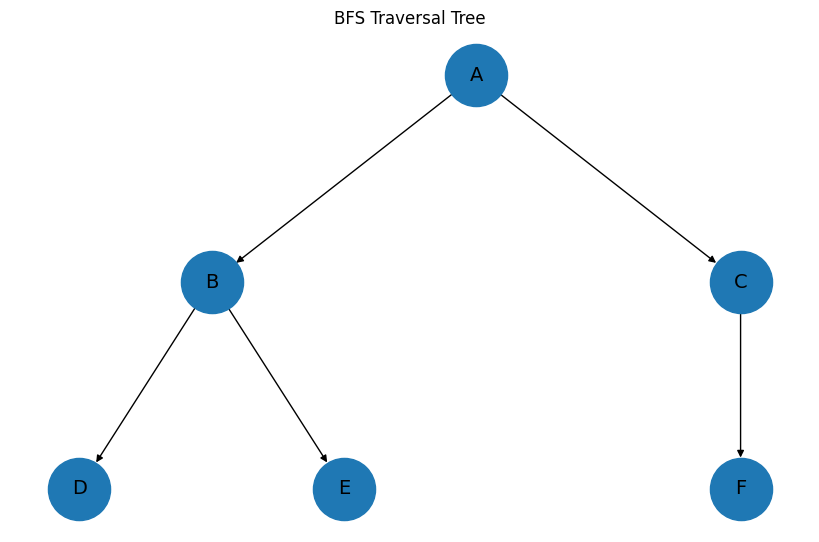

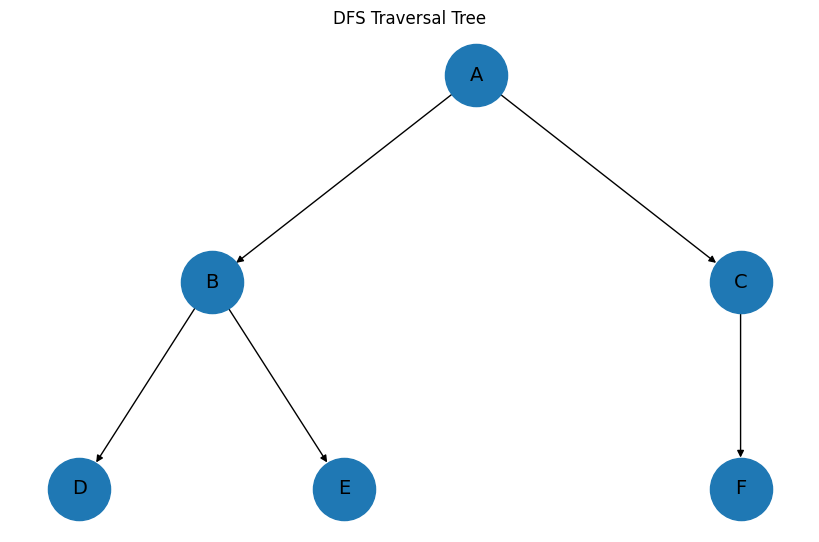

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# BFS Tree
bfs_tree = nx.DiGraph()

bfs_tree.add_edges_from([
    ('A', 'B'),
    ('A', 'C'),
    ('B', 'D'),
    ('B', 'E'),
    ('C', 'F')
])

# Draw BFS tree
plt.figure(figsize=(8, 5))
pos = {
    'A': (0, 2),
    'B': (-1, 1),
    'C': (1, 1),
    'D': (-1.5, 0),
    'E': (-0.5, 0),
    'F': (1, 0)
}

nx.draw(
    bfs_tree,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=14,
    arrows=True
)

plt.title("BFS Traversal Tree")
plt.show()


# DFS Tree
dfs_tree = nx.DiGraph()

dfs_tree.add_edges_from([
    ('A', 'B'),
    ('B', 'D'),
    ('B', 'E'),
    ('A', 'C'),
    ('C', 'F')
])

# Draw DFS tree
plt.figure(figsize=(8, 5))

nx.draw(
    dfs_tree,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=14,
    arrows=True
)

plt.title("DFS Traversal Tree")
plt.show()

Problem 2: Water Jug Problem Using BFS

In [4]:
from collections import deque
def water_jug_bfs(jug1_capacity, jug2_capacity, target):
    # A "state" is a tuple (amount in jug1, amount in jug2)
    start_state = (0, 0)
    visited = set([start_state])
    # queue holds (state, path_taken_so_far)
    queue = deque([(start_state, [start_state])])
    while queue:
        (x, y), path = queue.popleft()
        # Goal check: target amount present in either jug
        if x == target or y == target:
            return path
        # All 6 possible moves from state (x, y)
        possible_next_states = [
            (jug1_capacity, y), # Fill jug 1 completely
            (x, jug2_capacity), # Fill jug 2 completely
            (0, y), # Empty jug 1
            (x, 0), # Empty jug 2
            (x - min(x, jug2_capacity - y), y + min(x, jug2_capacity - y)), # Pour jug1 -> jug2
            (x + min(y, jug1_capacity - x), y - min(y, jug1_capacity - x)), # Pour jug2 -> jug1
        ]
        for state in possible_next_states:
            if state not in visited:
                visited.add(state)
                queue.append((state, path + [state]))
    return None # No solution found
# Step 1: Define the problem -> Jug A = 4 litres, Jug B = 3 litres, Target = 2 litres
jug1_capacity = 4
jug2_capacity = 3
target = 2
solution_path = water_jug_bfs(jug1_capacity, jug2_capacity, target)
print(f"Jug A capacity = {jug1_capacity} litres, Jug B capacity = {jug2_capacity}\nlitres")
print(f"Target amount to measure = {target} litres\n")
if solution_path:
    print("Solution found! Step-by-step states (Jug A, Jug B):")
    for step_number, state in enumerate(solution_path):
        print(f" Step {step_number}: {state}")
    print(f"\nTotal number of steps used = {len(solution_path) - 1}")
else:
    print("No solution exists for this combination.")

Jug A capacity = 4 litres, Jug B capacity = 3
litres
Target amount to measure = 2 litres

Solution found! Step-by-step states (Jug A, Jug B):
 Step 0: (0, 0)
 Step 1: (0, 3)
 Step 2: (3, 0)
 Step 3: (3, 3)
 Step 4: (4, 2)

Total number of steps used = 4


Problem 3: Checking Routes Between Cities Using DFS

Checking whether a road route exists between cities using DFS:

 Kolkata -> Ranchi ? YES, a route exists
 Kolkata -> Mumbai ? NO route exists
 Bankura -> Dhanbad ? YES, a route exists

Finding all separate groups of connected cities:
 Group 1: ['Kolkata', 'Durgapur', 'Bankura', 'Asansol', 'Dhanbad', 'Ranchi']
 Group 2: ['Mumbai', 'Pune']


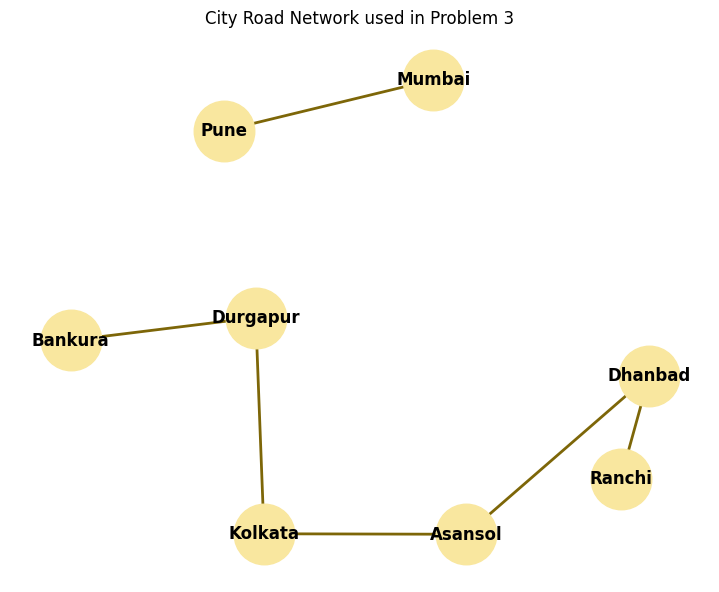

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
# Step 1: Represent a small road network as a graph (adjacency list)
# Notice 'Mumbai' and 'Pune' are connected to each other, but NOT to the rest of the map.
city_graph = {
'Kolkata': ['Durgapur', 'Asansol'],
'Durgapur': ['Kolkata', 'Bankura'],
'Asansol': ['Kolkata', 'Dhanbad'],
'Bankura': ['Durgapur'],
'Dhanbad': ['Asansol', 'Ranchi'],
'Ranchi': ['Dhanbad'],
'Mumbai': ['Pune'],
'Pune': ['Mumbai']
}
# Step 2: DFS function that checks if a path exists between two cities
def dfs_path_exists(graph, current_city, destination_city, visited=None):
    if visited is None:
        visited = set()
    visited.add(current_city)
    if current_city == destination_city:
        return True
    for neighbour_city in graph[current_city]:
        if neighbour_city not in visited:
            if dfs_path_exists(graph, neighbour_city, destination_city, visited):
                return True
    return False
# Step 3: DFS function that returns the full visited order (for connected components)
def dfs_traversal(graph, start_city, visited=None):
    if visited is None:
        visited = set()
    order = []
    visited.add(start_city)
    order.append(start_city)
    for neighbour_city in graph[start_city]:
        if neighbour_city not in visited:
            order.extend(dfs_traversal(graph, neighbour_city, visited))
    return order
# Step 4: Test whether a route exists between different city pairs
pairs_to_check = [('Kolkata', 'Ranchi'), ('Kolkata', 'Mumbai'), ('Bankura', 'Dhanbad')]
print("Checking whether a road route exists between cities using DFS:\n")
for city_a, city_b in pairs_to_check:
    result = dfs_path_exists(city_graph, city_a, city_b)
    status = "YES, a route exists" if result else "NO route exists"
    print(f" {city_a} -> {city_b} ? {status}")
# Step 5: Find all separate (disconnected) groups of cities using DFS
print("\nFinding all separate groups of connected cities:")
all_cities = list(city_graph.keys())
visited_overall = set()
group_number = 1
for city in all_cities:
    if city not in visited_overall:
        group = dfs_traversal(city_graph, city, visited_overall)
        print(f" Group {group_number}: {group}")
        group_number += 1
# Step 6: Draw the map
G = nx.Graph()
for city, neighbours in city_graph.items():
    for n in neighbours:
        G.add_edge(city, n)
plt.figure(figsize=(7, 5.5))
pos = nx.spring_layout(G, seed=11, k=1.6)
nx.draw(G, pos, with_labels=True, node_color='#F9E79F', node_size=1900,
font_size=12, font_weight='bold', edge_color='#7D6608', width=2)
plt.title("City Road Network used in Problem 3")
plt.show()